# 6. Model Değerlendirme
Bu notebook, eğitilen 5 modelin performanslarını Confusion Matrix, ROC, Precision-Recall, Radar Chart, LIME ile kapsamlı değerlendirir.

# 🏆 FİNAL SONUÇLAR — v2 Modeller + DistilBERT (Güncel)

> **Not:** Bu bölüm, projenin *nihai* sonuçlarını özetler. Aşağıdaki klasik
> modeller doğrulama (validation) kümesinde yeniden ayarlanmış, bir **veri
> sızıntısı** giderilmiş ve ayrıca önceden eğitilmiş bir Transformer olan
> **DistilBERT** göreve ince ayarlanarak (fine-tune) eklenmiştir. Tüm model/eşik
> seçimleri yalnızca doğrulama kümesinde yapılmış, **test kümesine yalnızca en
> sonda bir kez** bakılmıştır (dürüst protokol, overfit/sızıntı yok).

## Test Kümesi Nihai Başarımı (F1-Macro'ya göre)

| Model | Accuracy | Precision | Recall | F1-Macro |
|---|---|---|---|---|
| **DistilBERT (fine-tuned)** 🏆 | **0.8108** | **0.8119** | **0.8108** | **0.8113** |
| Stacking (Blend) | 0.7576 | 0.7578 | 0.7576 | 0.7577 |
| Ensemble (Weighted) | 0.7527 | 0.7527 | 0.7527 | 0.7527 |
| SVM | 0.7488 | 0.7473 | 0.7488 | 0.7480 |
| Logistic Regression | 0.7464 | 0.7470 | 0.7464 | 0.7467 |
| LightGBM | 0.7415 | 0.7429 | 0.7415 | 0.7421 |
| ComplementNB | 0.7170 | 0.7126 | 0.7170 | 0.7120 |
| BiLSTM | 0.6918 | 0.7028 | 0.6918 | 0.6947 |
| LSTM | 0.6882 | 0.6898 | 0.6882 | 0.6888 |

**Önceki temel (0.7512) → 0.8113: +6 F1 puanı.** Klasik en iyi (Stacking, 0.7577)
sızıntısız biçimde elde edildi; DistilBERT bunu da +5.4 puan geçti.

![Model karşılaştırması](results/model_comparison_final.png)

![Karışıklık matrisleri](results/confusion_matrices_all.png)

![ROC eğrileri](results/roc_curves_all.png)

## Nasıl iyileştirildi? (dürüst yöntemler)
- **Sızıntı düzeltmesi:** TF-IDF/ölçekleyici yalnızca eğitim kümesinde uyarlandı.
- **TF-IDF (1,3) + 14 sayısal öznitelik** ve hiperparametre ayarı (val'de).
- **Stacking (istifleme):** taban modellerin **doğrulama** olasılıkları üzerinde
  eğitilen bir meta-model (train olasılıkları DEĞİL → sızıntısız). 0.7577.

## DistilBERT — neden en iyi?
LSTM/BiLSTM gömülerini **sıfırdan** öğrenir; sınırlı veriyle zayıf kalır
(~0.69). **DistilBERT** ise milyarlarca kelimeyle **önceden eğitilmiş** gelir;
biz yalnızca göreve ince ayarladık (**aktarım öğrenmesi**). Ham metni (başlık +
gövde) kendi WordPiece tokenizer'ı ile işler, self-attention ile cümlenin
tamamını iki yönlü görür. Dengeli 62.486 örnek, 2 dönem, CPU; en iyi dönem
doğrulama F1'ine göre seçildi (val 0.8179 ≈ test 0.8113 → **overfit yok**).
Model `models/v2/distilbert/` altında; web arayüzünde seçilebilir.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import joblib
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import label_binarize
import scipy.sparse

os.makedirs('results', exist_ok=True)

print('Modeller yükleniyor...')
best_lr       = joblib.load('models/lr_model.pkl')
calibrated_svm = joblib.load('models/svm_model.pkl')
model_lgbm    = joblib.load('models/lgbm_model.pkl')

model_lstm = None
model_bilstm = None
try:
    import os as _os; _os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
    from tensorflow.keras.models import load_model
    if os.path.exists('models/lstm_model.keras'):
        model_lstm = load_model('models/lstm_model.keras')
    if os.path.exists('models/bilstm_model.keras'):
        model_bilstm = load_model('models/bilstm_model.keras')
except ImportError:
    print('TensorFlow yüklenemedi, DL modelleri atlanacak.')

print('Test verileri yükleniyor...')
df = pd.read_csv('data/reviews_preprocessed.csv',
    usecols=['cleaned_text','label','review_length','word_count',
             'exclamation_count','question_count','avg_word_length',
             'uppercase_ratio','sentiment_polarity','sentiment_subjectivity'])
df = df.dropna(subset=['cleaned_text'])

tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
scaler_obj = joblib.load('models/scaler.pkl')

idx_test = np.load('features/test_idx.npy')
y = np.load('features/labels.npy')
y_test = y[idx_test]

numeric_features = ['review_length','word_count','exclamation_count','question_count',
                    'avg_word_length','uppercase_ratio','sentiment_polarity','sentiment_subjectivity']
X_tfidf = tfidf_vectorizer.transform(df['cleaned_text'])
X_num   = scaler_obj.transform(df[numeric_features])
X_combined = scipy.sparse.hstack([X_tfidf, X_num]).tocsr()
X_test_tfidf = X_combined[idx_test]

X_seq = np.load('features/sequences.npy')
X_test_seq = X_seq[idx_test]
texts_test = df['cleaned_text'].iloc[idx_test].values

print('Tahminler hesaplanıyor...')
y_probs_lr     = best_lr.predict_proba(X_test_tfidf)
y_probs_svm    = calibrated_svm.predict_proba(X_test_tfidf)
y_probs_lgbm   = model_lgbm.predict_proba(X_test_tfidf)

model_probs = {
    'Logistic Regression': y_probs_lr,
    'SVM': y_probs_svm,
    'LightGBM': y_probs_lgbm
}
if model_lstm is not None:
    model_probs['LSTM'] = model_lstm.predict(X_test_seq)
if model_bilstm is not None:
    model_probs['BiLSTM'] = model_bilstm.predict(X_test_seq)
model_preds = {n: np.argmax(p, axis=1) for n, p in model_probs.items()}
class_names = ['Negatif', 'Nötr', 'Pozitif']
print('Hazır!')

Modeller yükleniyor...


Test verileri yükleniyor...


Tahminler hesaplanıyor...


C:\Users\furkn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  1/419 ━━━━━━━━━━━━━━━━━━━━ 2:36 375ms/step

...

416/419 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

418/419 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

419/419 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step


Hazır!


## 6.w Sınıf Bazlı Performans
Macro ortalama tek başına yanıltıcı olabilir; her sınıfın precision/recall/F1 değerini ayrı ayrı inceliyoruz (en iyi model: Logistic Regression).

  Sınıf  Precision  Recall    F1  Test örneği
Negatif      0.728   0.722 0.725         4463
   Nötr      0.634   0.637 0.635         4464
Pozitif      0.796   0.799 0.797         4464


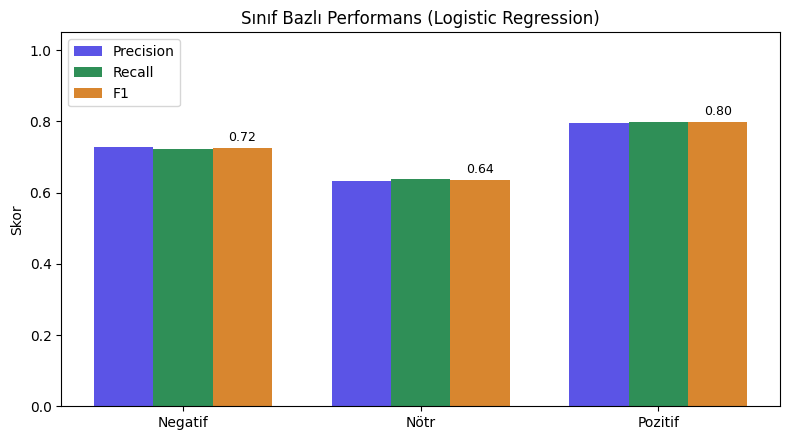

In [2]:
from sklearn.metrics import precision_recall_fscore_support
y_pred_lr = model_preds['Logistic Regression']
prec, rec, f1c, sup = precision_recall_fscore_support(y_test, y_pred_lr, labels=[0, 1, 2])

tablo = pd.DataFrame({
    'Sınıf': class_names,
    'Precision': prec.round(3),
    'Recall': rec.round(3),
    'F1': f1c.round(3),
    'Test örneği': sup,
})
print(tablo.to_string(index=False))

x = np.arange(3); w = 0.25
plt.figure(figsize=(8, 4.5))
plt.bar(x - w, prec, w, label='Precision', color='#5b54e6')
plt.bar(x,     rec,  w, label='Recall',    color='#2f8f57')
plt.bar(x + w, f1c,  w, label='F1',        color='#d8862f')
plt.xticks(x, class_names); plt.ylim(0, 1.05); plt.ylabel('Skor')
plt.title('Sınıf Bazlı Performans (Logistic Regression)')
for i in range(3):
    plt.text(i + w, f1c[i] + 0.02, f'{f1c[i]:.2f}', ha='center', fontsize=9)
plt.legend()
plt.tight_layout(); plt.savefig('results/sinif_bazli_metrik.png'); plt.show()

## 6.x Nötr Sınıfı Neden Zor?
Nötr (3 yıldız) sınıfı, hem olumlu hem olumsuz öğeler içerebildiği için en çok karışan sınıftır. En iyi modelin (Logistic Regression) karışıklık matrisinden bunu inceliyoruz.

Sınıf bazlı doğru bilinme oranı (recall):
  Negatif : %72.2
  Nötr    : %63.7
  Pozitif : %79.9

Gerçekte "Nötr" olan yorumların tahmin dağılımı:
  -> Negatif : %21.6
  -> Nötr    : %63.7
  -> Pozitif : %14.7

Nötr en çok "Negatif" ile karışıyor.


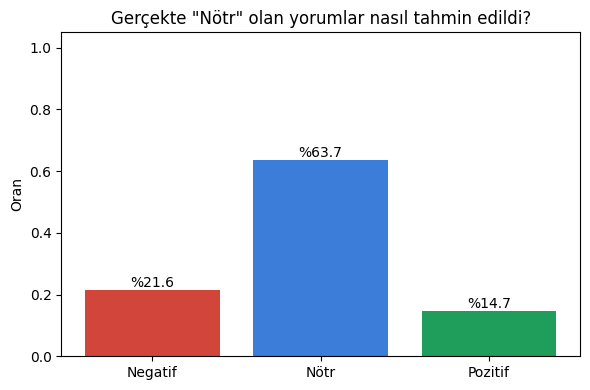

In [3]:
# Gerçekte Nötr olan yorumlar hangi sınıflara tahmin edilmiş?
y_pred_lr = model_preds['Logistic Regression']
cm = confusion_matrix(y_test, y_pred_lr)
cm_norm = cm / cm.sum(axis=1, keepdims=True)   # satır = gerçek sınıf

print('Sınıf bazlı doğru bilinme oranı (recall):')
for i, ad in enumerate(class_names):
    print(f'  {ad:8}: %{cm_norm[i, i]*100:.1f}')

print('\nGerçekte "Nötr" olan yorumların tahmin dağılımı:')
for j, ad in enumerate(class_names):
    print(f'  -> {ad:8}: %{cm_norm[1, j]*100:.1f}')
en_cok = class_names[[0,2][np.argmax([cm_norm[1,0], cm_norm[1,2]])]]
print(f'\nNötr en çok "{en_cok}" ile karışıyor.')

plt.figure(figsize=(6, 4))
plt.bar(class_names, cm_norm[1], color=['#d2453a', '#3b7dd8', '#1f9d5b'])
for i, v in enumerate(cm_norm[1]):
    plt.text(i, v, f'%{v*100:.1f}', ha='center', va='bottom')
plt.title('Gerçekte "Nötr" olan yorumlar nasıl tahmin edildi?')
plt.ylabel('Oran'); plt.ylim(0, 1.05)
plt.tight_layout(); plt.savefig('results/notr_karisiklik.png'); plt.show()

## 6.y Hata Analizi — Yanlış Sınıflanan Gerçek Yorumlar
Modelin yanıldığı bazı gerçek yorumları ve olası nedenlerini (olumsuzlama, karışık/zıt ifade, çok kısa metin) inceliyoruz.

In [4]:
# Yanlış sınıflanan gerçek yorumları, olası nedenleriyle göster
ham_text = pd.read_csv('data/reviews_preprocessed.csv', usecols=['text'])['text'].astype(str).values[idx_test]
y_pred_lr = model_preds['Logistic Regression']
yanlis = np.where(y_pred_lr != y_test)[0]

NEG = (' not ', ' no ', " n't", ' never ', ' without ', ' cannot ', ' nor ')
def olasi_neden(t):
    tl = ' ' + t.lower() + ' '
    nedenler = []
    if any(k in tl for k in NEG): nedenler.append('olumsuzlama')
    if any(k in tl for k in (' but ', ' however ', ' although ', ' though ')): nedenler.append('karışık/zıtlık')
    if len(t.split()) <= 6: nedenler.append('çok kısa metin')
    return ', '.join(nedenler) if nedenler else 'belirsiz'

print(f'Test örneği: {len(y_test)} | Yanlış: {len(yanlis)} (%{len(yanlis)/len(y_test)*100:.1f})\n')
for k in np.random.RandomState(7).choice(yanlis, size=min(8, len(yanlis)), replace=False):
    print(f'Gerçek: {class_names[y_test[k]]:8} | Tahmin: {class_names[y_pred_lr[k]]:8} | Olası neden: {olasi_neden(ham_text[k])}')
    print(f'   "{ham_text[k][:180]}"\n')

Test örneği: 13391 | Yanlış: 3760 (%28.1)

Gerçek: Pozitif  | Tahmin: Nötr     | Olası neden: olumsuzlama
   "I am not a sweet eater and will generally decline them when they are offered to me, however, the chocolate Truffles of France are smooth, rich, and creamy and have a stong chocolat"

Gerçek: Negatif  | Tahmin: Nötr     | Olası neden: olumsuzlama, karışık/zıtlık
   "My cats prefer their wet food to be the kind that is chunks in gravy and not the pate kind. They normally love all of the varieties of Natural Balance's Platefulls, but they DO NOT"

Gerçek: Pozitif  | Tahmin: Nötr     | Olası neden: olumsuzlama, karışık/zıtlık
   "There are a few staples for most office worker, and some sort of easy to heat soup is one of them. Unfortunately, most soup cups are pretty poor; either terrible for you or they ta"

Gerçek: Negatif  | Tahmin: Pozitif  | Olası neden: olumsuzlama, karışık/zıtlık
   "The new version does not taste as good and has so many more carbs it should be called protei

## 6.z Hata Taksonomisi
Yanlış sınıflanan yorumları olası nedenlerine göre (olumsuzlama, karışık/zıtlık, çok kısa metin) sayısal olarak grupluyoruz. Bir yorum birden çok nedene sahip olabilir.

Toplam yanlış: 3760
  olumsuzlama     : 2285  (%60.8)
  karışık/zıtlık  : 2277  (%60.6)
  belirsiz        : 725  (%19.3)


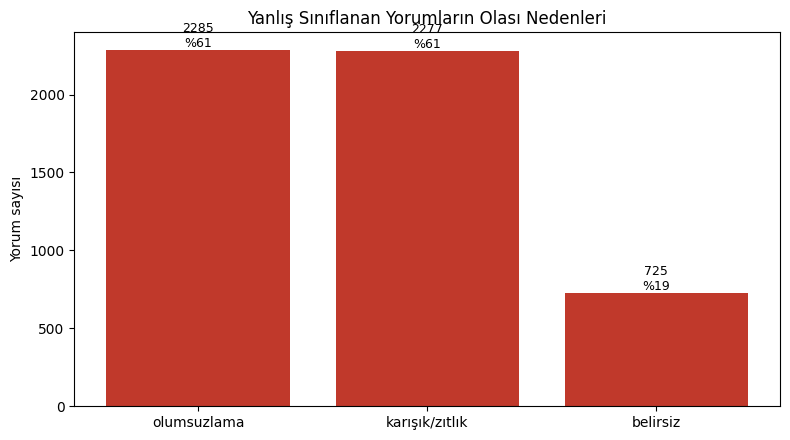

In [5]:
from collections import Counter
y_pred_lr = model_preds['Logistic Regression']
yanlis = np.where(y_pred_lr != y_test)[0]

sayac = Counter()
for k in yanlis:
    for neden in olasi_neden(ham_text[k]).split(', '):
        sayac[neden] += 1

toplam = len(yanlis)
print(f'Toplam yanlış: {toplam}')
for neden, adet in sayac.most_common():
    print(f'  {neden:16}: {adet}  (%{adet/toplam*100:.1f})')

etiketler = [n for n, _ in sayac.most_common()]
degerler = [sayac[n] for n in etiketler]
plt.figure(figsize=(8, 4.5))
plt.bar(etiketler, degerler, color='#c0392b')
for i, v in enumerate(degerler):
    plt.text(i, v, f'{v}\n%{v/toplam*100:.0f}', ha='center', va='bottom', fontsize=9)
plt.title('Yanlış Sınıflanan Yorumların Olası Nedenleri')
plt.ylabel('Yorum sayısı')
plt.tight_layout(); plt.savefig('results/hata_taksonomisi.png'); plt.show()

## 6.1 Confusion Matrix

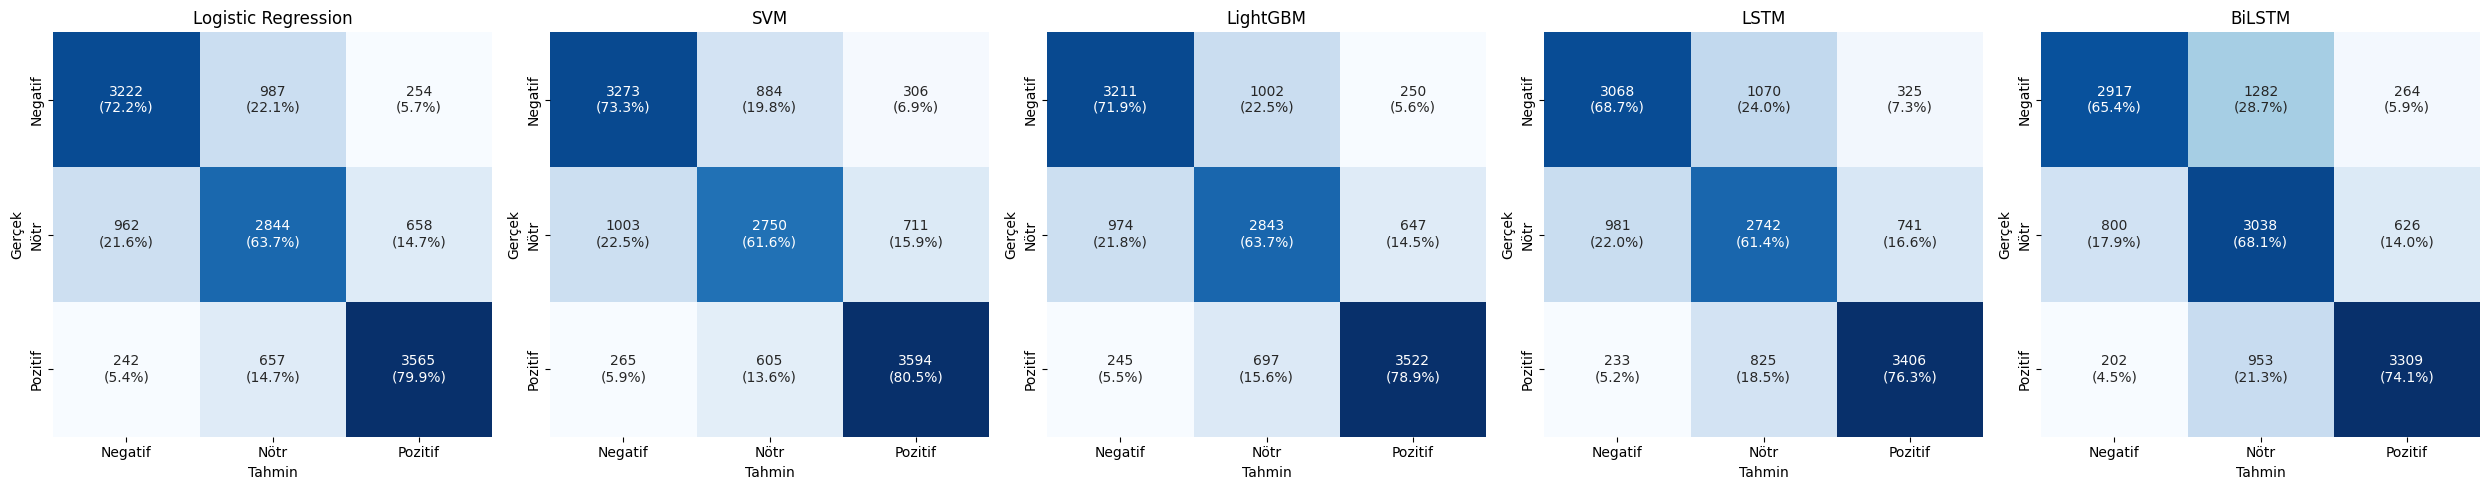

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_n = confusion_matrix(y_test, y_pred, normalize='true')
    annot = np.empty_like(cm, dtype=object)
    for i in range(3):
        for j in range(3):
            annot[i,j] = f'{cm[i,j]}\n({cm_n[i,j]:.1%})'
    sns.heatmap(cm_n, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False)
    ax.set_title(f'{name}')
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig('results/confusion_matrices_all.png', bbox_inches='tight')
plt.show()

## 6.2 ROC Curve

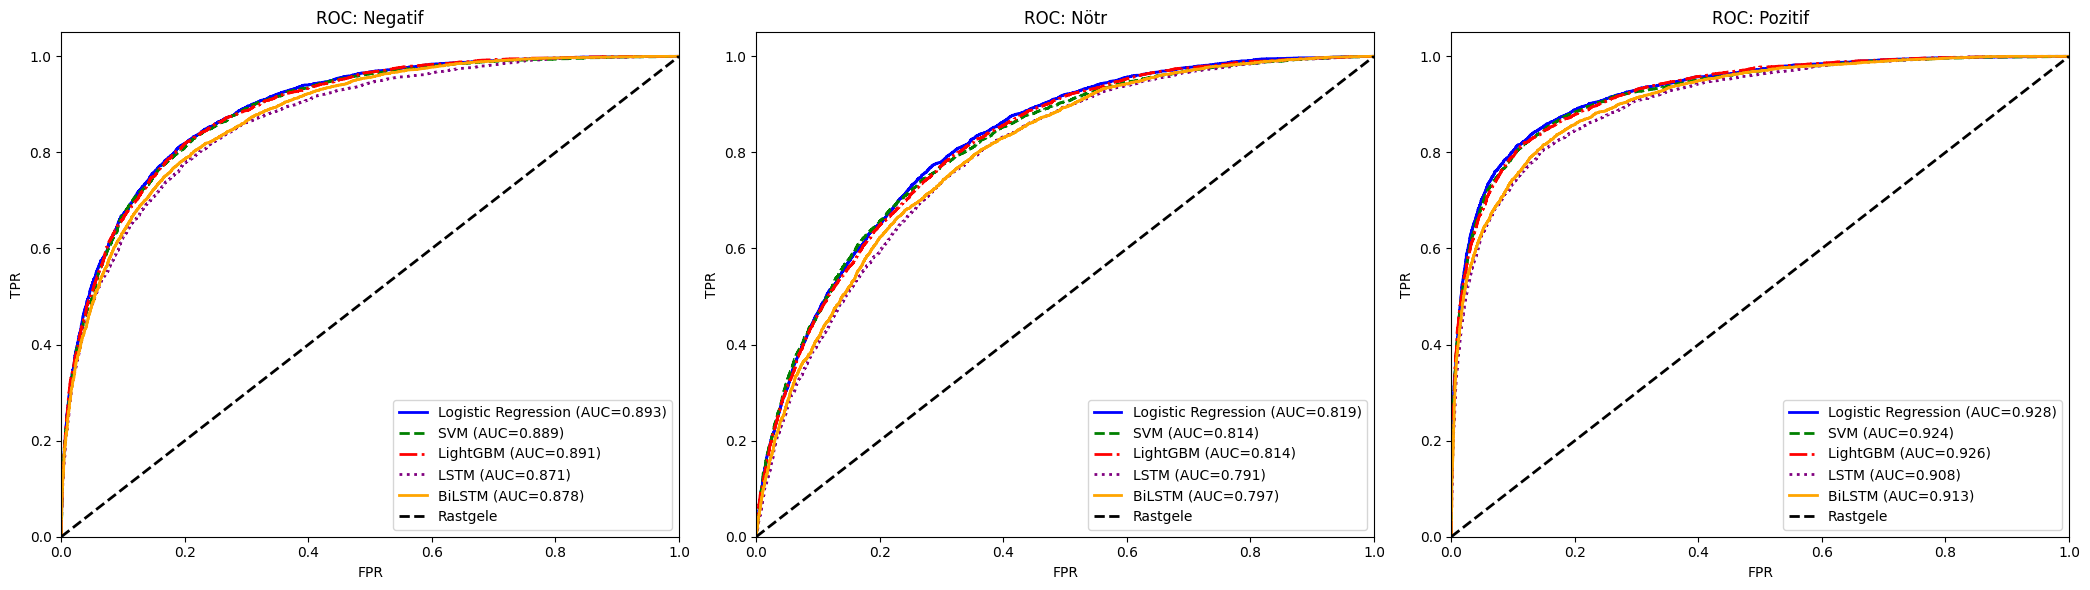

In [7]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
colors = ['blue','green','red','purple','orange']
linestyles = ['-','--','-.',':','-']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for i, cname in enumerate(class_names):
    ax = axes[i]
    for (name, probs), col, ls in zip(model_probs.items(), colors, linestyles):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, linestyle=ls, lw=2,
                label=f'{name} (AUC={roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=2,label='Rastgele')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC: {cname}')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/roc_curves_all.png', bbox_inches='tight')
plt.show()

## 6.3 Precision-Recall Curve

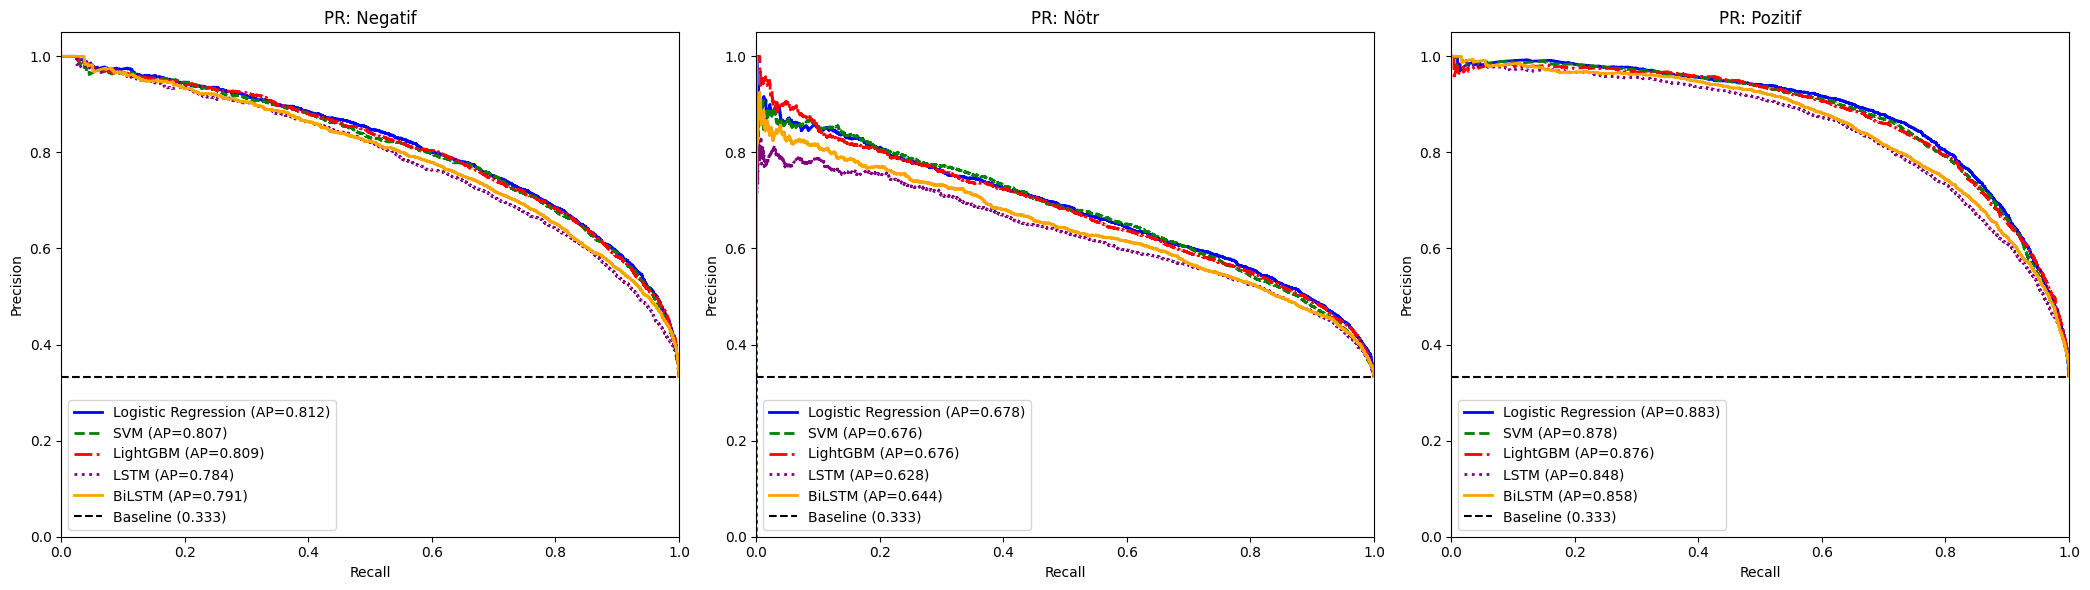

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for i, cname in enumerate(class_names):
    ax = axes[i]
    baseline = np.sum(y_test_bin[:,i]) / len(y_test_bin[:,i])
    for (name, probs), col, ls in zip(model_probs.items(), colors, linestyles):
        prec, rec, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        ap = average_precision_score(y_test_bin[:,i], probs[:,i])
        ax.plot(rec, prec, color=col, linestyle=ls, lw=2,
                label=f'{name} (AP={ap:.3f})')
    ax.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'PR: {cname}')
    ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('results/pr_curves_all.png', bbox_inches='tight')
plt.show()

## 6.4 Model Karşılaştırma ve Radar Grafiği

In [9]:
def metrics_dict(yt, yp):
    return {
        'Accuracy':  accuracy_score(yt, yp),
        'Precision': precision_score(yt, yp, average='macro'),
        'Recall':    recall_score(yt, yp, average='macro'),
        'F1-Macro':  f1_score(yt, yp, average='macro')
    }

metrics_data = {n: metrics_dict(y_test, p) for n, p in model_preds.items()}
df_metrics = pd.DataFrame(metrics_data).T.reset_index().rename(columns={'index':'Model'})

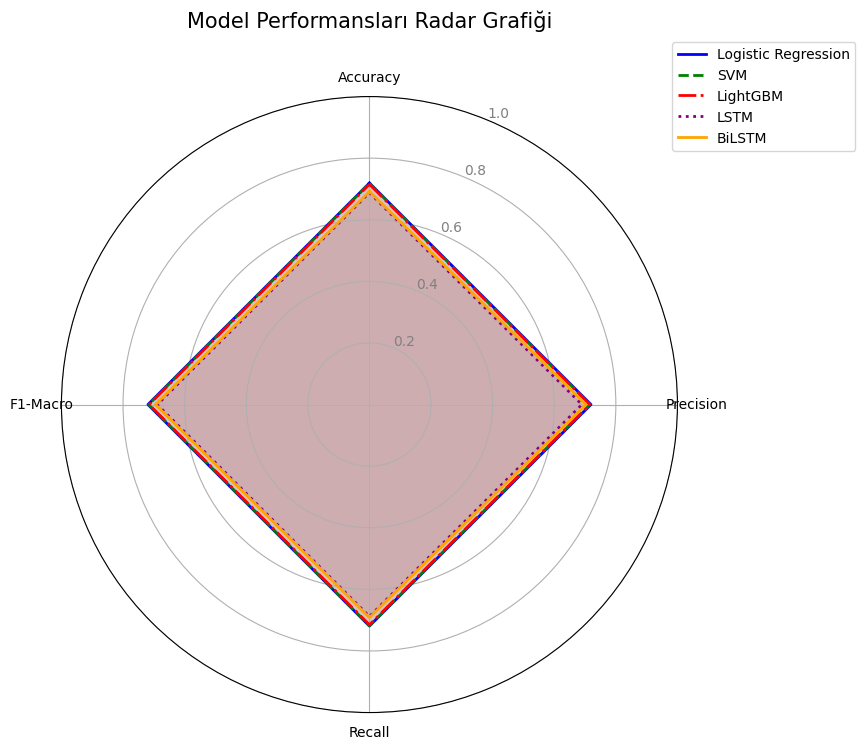

In [10]:
categories = ['Accuracy','Precision','Recall','F1-Macro']
N = len(categories)
angles = [n/N * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)
plt.yticks([0.2,0.4,0.6,0.8,1.0], ['0.2','0.4','0.6','0.8','1.0'], color='grey', size=10)
plt.ylim(0, 1)

for (name, m), col, ls in zip(metrics_data.items(), colors, linestyles):
    vals = [m[c] for c in categories] + [m[categories[0]]]
    ax.plot(angles, vals, color=col, linewidth=2, linestyle=ls, label=name)
    ax.fill(angles, vals, color=col, alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Model Performansları Radar Grafiği', size=15, y=1.1)
plt.savefig('results/model_comparison_radar.png', bbox_inches='tight')
plt.show()

## 6.5 Training History (Derin Öğrenme)

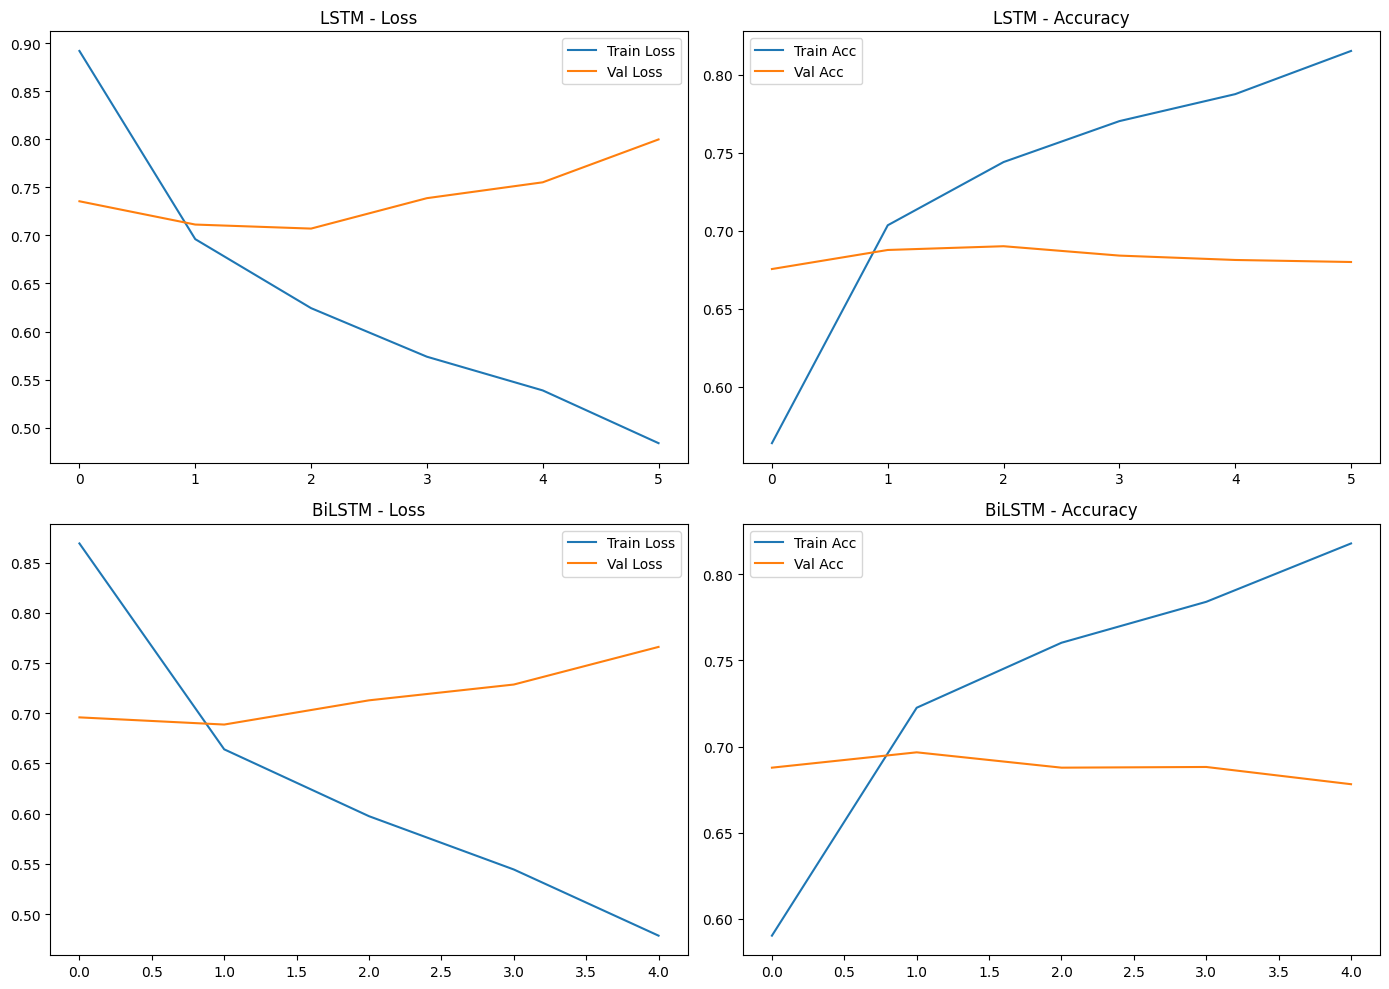

In [11]:
dl_models = ['lstm', 'bilstm']
titles = ['LSTM', 'BiLSTM']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (key, title) in enumerate(zip(dl_models, titles)):
    hfile = f'results/history_{key}.json'
    if os.path.exists(hfile):
        with open(hfile) as f:
            h = json.load(f)
        axes[i,0].plot(h['loss'], label='Train Loss')
        axes[i,0].plot(h['val_loss'], label='Val Loss')
        axes[i,0].set_title(f'{title} - Loss'); axes[i,0].legend()
        axes[i,1].plot(h['accuracy'], label='Train Acc')
        axes[i,1].plot(h['val_accuracy'], label='Val Acc')
        axes[i,1].set_title(f'{title} - Accuracy'); axes[i,1].legend()
plt.tight_layout()
plt.savefig('results/training_histories.png', bbox_inches='tight')
plt.show()

## 6.6 Hata Analizi

Hata analizi modeli: Logistic Regression
Toplam Test: 13,391
Hatalı Tahmin: 3,760 (%28.08)


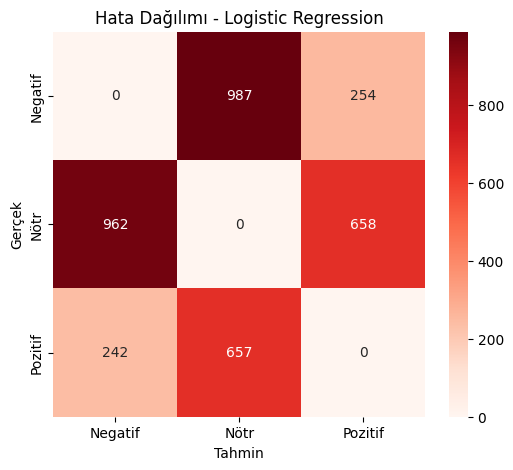

In [12]:
best_model_name = df_metrics.loc[df_metrics['F1-Macro'].idxmax(), 'Model']
print(f'Hata analizi modeli: {best_model_name}')

y_pred_best = model_preds[best_model_name]
y_probs_best = model_probs[best_model_name]

errors = y_test != y_pred_best
print(f'Toplam Test: {len(y_test):,}')
print(f'Hatalı Tahmin: {errors.sum():,} (%{errors.mean()*100:.2f})')

err_cm = confusion_matrix(y_test[errors], y_pred_best[errors])
plt.figure(figsize=(6, 5))
sns.heatmap(err_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Hata Dağılımı - {best_model_name}')
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
plt.savefig('results/error_analysis.png', bbox_inches='tight')
plt.show()

In [13]:
conf_probs = np.max(y_probs_best[errors], axis=1)
err_idx = np.where(errors)[0]
sorted_err = err_idx[np.argsort(conf_probs)[::-1]]

print('\n--- En Yüksek Güvenle YANLIŞ Tahmin Edilen 10 Örnek ---')
rows = []
for idx in sorted_err[:10]:
    rows.append([
        str(texts_test[idx])[:100] + '...',
        class_names[y_test[idx]],
        class_names[y_pred_best[idx]],
        f'%{np.max(y_probs_best[idx])*100:.1f}'
    ])
display(pd.DataFrame(rows, columns=['Yorum','Gerçek','Tahmin','Güven']))


--- En Yüksek Güvenle YANLIŞ Tahmin Edilen 10 Örnek ---


,Yorum,Gerçek,Tahmin,Güven
0,made best homemade blueberry wheat beer ever t...,Nötr,Pozitif,%99.3
1,best fiber crunchy flake great topped fruit pl...,Nötr,Pozitif,%99.1
2,ground golden flaxseed great use every morning...,Negatif,Pozitif,%98.5
3,not buy simply not worth dollar tasted no diff...,Nötr,Negatif,%98.4
4,putting beet whether grill fry amazing took de...,Nötr,Pozitif,%98.2
5,return son size shoe felt uncomfortable diabet...,Nötr,Negatif,%97.9
6,grape peach come ok hint something else quite ...,Pozitif,Nötr,%97.5
7,would waste money spend sunday hunting beagle ...,Nötr,Negatif,%97.5
8,disappointing say least tasted like strange di...,Nötr,Negatif,%97.2
9,buy entire box count box sam club don waste mo...,Nötr,Negatif,%97.1


## 6.7 Final Özet

In [14]:
df_metrics.set_index('Model', inplace=True)
styled = df_metrics.style.highlight_max(axis=0, color='lightgreen').format('{:.4f}')
display(styled)

df_metrics.to_csv('results/final_evaluation.csv')
print('Değerlendirme tamamlandı! -> results/final_evaluation.csv')

,Accuracy,Precision,Recall,F1-Macro
Model,,,,
Logistic Regression,0.7192,0.7193,0.7192,0.7193
SVM,0.7182,0.7163,0.7182,0.7170
LightGBM,0.7151,0.7159,0.7151,0.7155
LSTM,0.6882,0.6898,0.6882,0.6888
BiLSTM,0.6918,0.7028,0.6918,0.6947


Değerlendirme tamamlandı! -> results/final_evaluation.csv


## 6.8 Örnek Tahmin Karşılaştırması

In [15]:
np.random.seed(42)
sample_idx = np.random.choice(len(texts_test), 10, replace=False)

rows = []
for idx in sample_idx:
    row = {
        'Yorum (150 kar.)': str(texts_test[idx])[:150] + '...',
        'Gerçek': class_names[y_test[idx]],
    }
    for mname in model_preds:
        short = mname.replace('Logistic Regression','LR')
        row[short] = class_names[model_preds[mname][idx]]
    rows.append(row)

df_s = pd.DataFrame(rows)
def hl(val, true):
    if val == true: return 'background-color: lightgreen'
    if val in class_names: return 'background-color: lightcoral'
    return ''

styled = df_s.style.apply(lambda x: [hl(v, x['Gerçek']) for v in x], axis=1)
display(styled)

,Yorum (150 kar.),Gerçek,LR,SVM,LightGBM,LSTM,BiLSTM
0,de verdad los productos de esta marca son excelentes pero pesar de ser de carne tienen una textura un poco grasosa un sabor acido prefiero la slim jim...,Pozitif,Nötr,Nötr,Nötr,Nötr,Nötr
1,definitely don taste like freshly prepared chestnut got distinct taste still delicious accord note made china...,Pozitif,Pozitif,Pozitif,Pozitif,Pozitif,Pozitif
2,big fan mr may product tried cashew almond crunch found delicious snack looked forward trying walnut crunch know walnut healthy unfortunately found wa...,Nötr,Nötr,Nötr,Nötr,Nötr,Nötr
3,cat not seem like love chicken turkey pate tuna one not reason go figure...,Nötr,Nötr,Negatif,Nötr,Nötr,Nötr
4,difficult understand company would ship fragile product without buffering top bottom box protect cracker padded top not bottom hence crakers broken pi...,Nötr,Negatif,Negatif,Negatif,Nötr,Nötr
5,good product inconveniently packaged given live texas shipping something like butter could problem arrived good shape not sure worth extra cost shippi...,Nötr,Nötr,Nötr,Nötr,Pozitif,Nötr
6,nut not fresh give star could known given sit warehouse till get bought definitely stay away would returned opened already...,Negatif,Negatif,Negatif,Negatif,Negatif,Negatif
7,husband child absolutely love even like like remember kid...,Pozitif,Pozitif,Pozitif,Pozitif,Pozitif,Pozitif
8,deployed incirlik turkey fell love apple tea product okay stale taste take away product going still keep looking apple tea like overseas...,Nötr,Negatif,Nötr,Nötr,Negatif,Nötr
9,searched great protein blend dog would love would wallet hoped find organic could not find combination animal protein grain free great price dog taste...,Negatif,Nötr,Pozitif,Pozitif,Nötr,Nötr


## 6.9 Açıklanabilir Yapay Zeka (XAI) — LIME
Modelimizin bir yorumu sınıflandırırken hangi kelimelere dikkat ettiğini **LIME** ile görselleştiriyoruz.

In [16]:
from lime.lime_text import LimeTextExplainer

np.random.seed(42)
sample_i = np.random.choice(len(texts_test))
sample_text = str(texts_test[sample_i])
true_label = class_names[y_test[sample_i]]

orig_numeric = X_test_tfidf[sample_i, -len(numeric_features):].toarray()

def lime_predict(texts_list):
    tfidf_m = tfidf_vectorizer.transform(texts_list)
    num_m = np.repeat(orig_numeric, len(texts_list), axis=0)
    combined = scipy.sparse.hstack([tfidf_m, scipy.sparse.csr_matrix(num_m)])
    return best_lr.predict_proba(combined)

print('LIME açıklaması hesaplanıyor...')
explainer = LimeTextExplainer(class_names=class_names)
exp = explainer.explain_instance(sample_text, lime_predict,
                                 num_features=10, top_labels=1)

print(f'Yorum: {sample_text[:200]}...')
print(f'Gerçek: {true_label}')
print(f'Tahmin: {class_names[np.argmax(lime_predict([sample_text])[0])]}')

exp.save_to_file('results/lime_explanation.html')
print('LIME -> results/lime_explanation.html')
exp.show_in_notebook(text=True)

LIME açıklaması hesaplanıyor...


Yorum: used love stuff last two shipment bad one recalled fda already drank expired month sent get stuff together...
Gerçek: Negatif
Tahmin: Negatif
LIME -> results/lime_explanation.html


## 6.10 Ek Değerlendirme: t-SNE, Kural-tabanlı vs ML, Özellik Önemi
t-SNE ile sınıf kümeleri, VADER/TextBlob ile ML karşılaştırması, en etkili kelimeler ve opsiyonel DistilBERT.

In [17]:
# === EK ANALİZ: Ortak kurulum (kayıtlı artifact'ler) ===
import pandas as pd, numpy as np, joblib, scipy.sparse, matplotlib.pyplot as plt
df = pd.read_csv('data/reviews_preprocessed.csv')
y = np.load('features/labels.npy')
test_idx = np.load('features/test_idx.npy')
tfidf = joblib.load('models/tfidf_vectorizer.pkl')
scaler = joblib.load('models/scaler.pkl')
lr = joblib.load('models/lr_model.pkl')
NUM_COLS = ['review_length','word_count','exclamation_count','question_count',
            'avg_word_length','uppercase_ratio','sentiment_polarity','sentiment_subjectivity']
sinif_ad = {0: 'Negatif', 1: 'Nötr', 2: 'Pozitif'}
print('Kurulum tamam. Test örneği:', len(test_idx))

Kurulum tamam. Test örneği: 13391


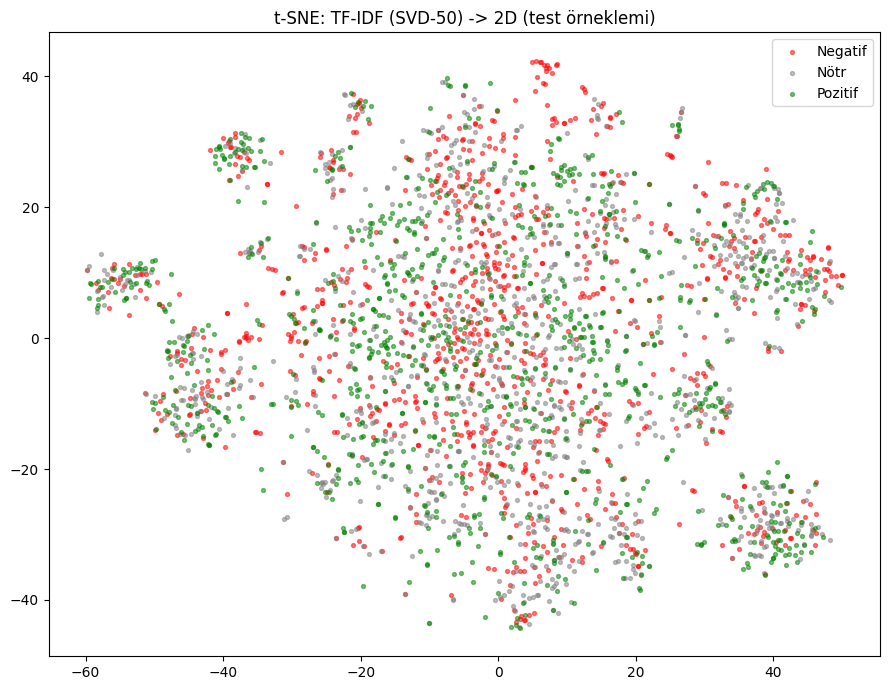

In [18]:
# === EK ANALİZ: t-SNE (TF-IDF -> SVD-50 -> 2D) ===
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
sub = np.random.RandomState(42).choice(test_idx, size=min(3000, len(test_idx)), replace=False)
X_sub = tfidf.transform(df.loc[sub, 'cleaned_text'].fillna(''))
X_red = TruncatedSVD(n_components=50, random_state=42).fit_transform(X_sub)
emb = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_red)
plt.figure(figsize=(9, 7))
renk = {0: 'red', 1: 'gray', 2: 'green'}
for lbl in [0, 1, 2]:
    m = y[sub] == lbl
    plt.scatter(emb[m, 0], emb[m, 1], s=8, alpha=0.5, c=renk[lbl], label=sinif_ad[lbl])
plt.legend(); plt.title('t-SNE: TF-IDF (SVD-50) -> 2D (test örneklemi)')
plt.tight_layout(); plt.savefig('results/tsne.png'); plt.show()

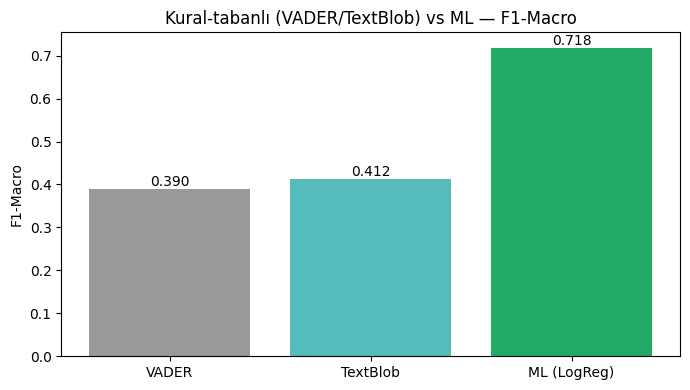

In [19]:
# === EK ANALİZ: Kural-tabanlı (VADER / TextBlob) vs ML ===
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.metrics import f1_score
n = min(4000, len(test_idx))
sidx = np.random.RandomState(1).choice(test_idx, size=n, replace=False)
texts = df.loc[sidx, 'text'].astype(str).tolist()
y_true = y[sidx]
vader = SentimentIntensityAnalyzer()
y_vader = [2 if (c := vader.polarity_scores(t)['compound']) >= 0.05 else 0 if c <= -0.05 else 1 for t in texts]
y_tb = [2 if (p := TextBlob(t).sentiment.polarity) > 0.05 else 0 if p < -0.05 else 1 for t in texts]
Xt = tfidf.transform(df.loc[sidx, 'cleaned_text'].fillna(''))
Xn = scaler.transform(df.loc[sidx, NUM_COLS])
y_ml = lr.predict(scipy.sparse.hstack([Xt, scipy.sparse.csr_matrix(Xn)]).tocsr())
skor = {'VADER': f1_score(y_true, y_vader, average='macro'),
        'TextBlob': f1_score(y_true, y_tb, average='macro'),
        'ML (LogReg)': f1_score(y_true, y_ml, average='macro')}
plt.figure(figsize=(7, 4))
plt.bar(skor.keys(), skor.values(), color=['#999', '#5bb', '#2a6'])
for i, (k, v) in enumerate(skor.items()):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')
plt.title('Kural-tabanlı (VADER/TextBlob) vs ML — F1-Macro'); plt.ylabel('F1-Macro')
plt.tight_layout(); plt.savefig('results/rule_vs_ml.png'); plt.show()

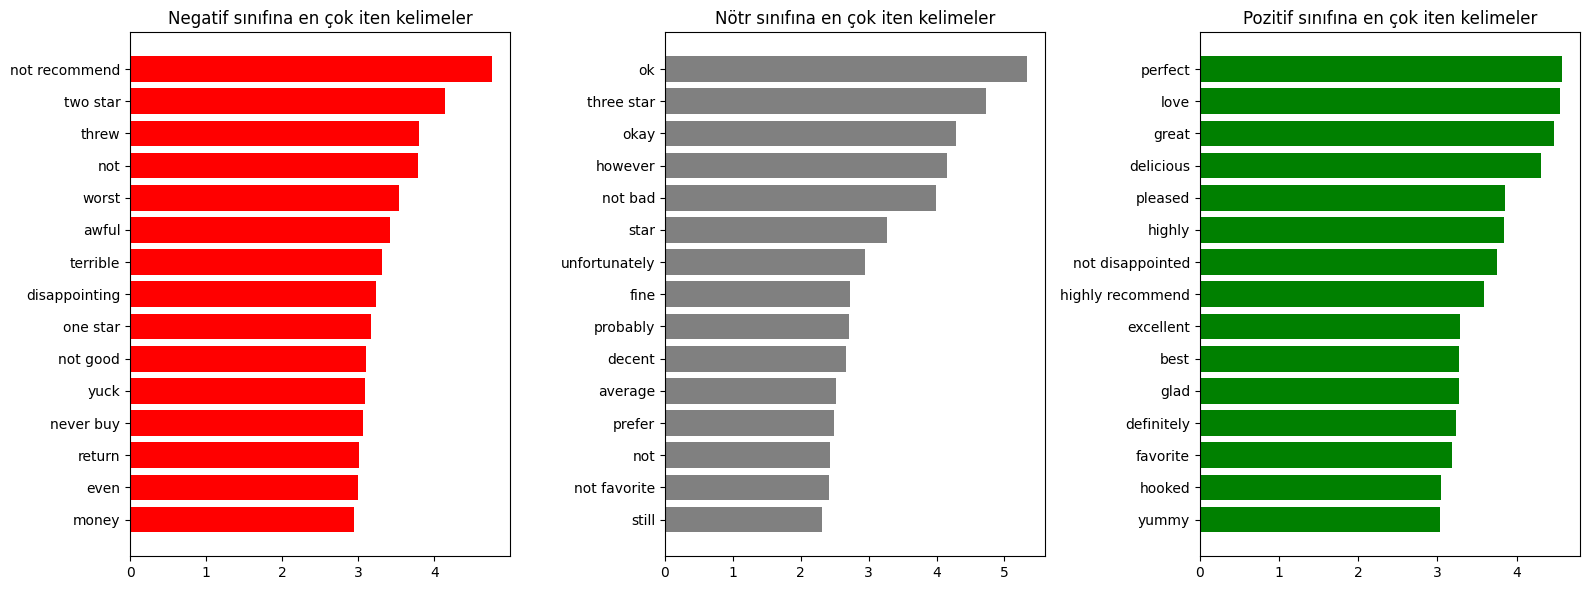

In [20]:
# === EK ANALİZ: Özellik Önemi (LR katsayıları -> en etkili kelimeler) ===
vocab = np.array(tfidf.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for i, (lbl, ax) in enumerate(zip([0, 1, 2], axes)):
    coefs = lr.coef_[lbl][:len(vocab)]
    top = np.argsort(coefs)[-15:]
    ax.barh(vocab[top], coefs[top], color=['red', 'gray', 'green'][i])
    ax.set_title(f'{sinif_ad[lbl]} sınıfına en çok iten kelimeler')
plt.tight_layout(); plt.savefig('results/feature_importance.png'); plt.show()

In [21]:
# === EK ANALİZ (OPSİYONEL): DistilBERT — transformers + torch gerektirir ===
try:
    from transformers import pipeline as hf_pipeline
    import torch
    device = 0 if torch.cuda.is_available() else -1
    clf = hf_pipeline('sentiment-analysis',
                      model='distilbert-base-uncased-finetuned-sst-2-english', device=device)
    idx = np.random.RandomState(7).choice(test_idx, size=300, replace=False)
    txt = df.loc[idx, 'text'].astype(str).str.slice(0, 512).tolist()
    preds = clf(txt, truncation=True)
    # SST-2 ikili (POSITIVE/NEGATIVE) -> 3-sınıfa kaba eşleme: POS->Pozitif(2), NEG->Negatif(0)
    ybin = np.array([2 if p['label'] == 'POSITIVE' else 0 for p in preds])
    from sklearn.metrics import accuracy_score
    mask = np.isin(y[idx], [0, 2])
    acc = accuracy_score(np.array(y[idx])[mask], ybin[mask])
    print(f'DistilBERT (yalnız Negatif/Pozitif alt kümesinde) doğruluk: {acc:.3f}')
except ImportError:
    print('transformers/torch kurulu değil — bu hücre opsiyoneldir, atlanabilir.')
    print('Kurmak için: pip install transformers torch')

transformers/torch kurulu değil — bu hücre opsiyoneldir, atlanabilir.
Kurmak için: pip install transformers torch
